## Import Libraries and Functions

In [6]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

import hierarchical_position_classifier as hpc_module

importlib.reload(hpc_module)

from hierarchical_position_classifier import (
    combine_position_experiment_summaries,
    per_room_hierarchical_summary,
    run_global_position_experiments_by_split,
    run_global_position_experiments_by_split_knn,
    run_hierarchical_position_experiments_by_split,
    run_hierarchical_position_experiments_by_split_knn,
    summarize_distance_errors,
)
from utils.csi_preprocessing import process_magnitude_data
from utils.feature_pipeline import build_frequency_feature_dataframes
import utils.graphs as graphs

importlib.reload(graphs)

from utils.graphs import (
    plot_band_error_boxplot,
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_position_confusion_by_true_room,
    plot_position_confusion_when_room_correct,
)
from utils.import_data import get_csv_files, sort_meta_info
from utils.thesis_csv_processing import process_csv_files
from utils.cache import get_all_dataframes, get_results_path, save_summary, write_manifest


## Configuration

In [7]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "CSI DATA"
CALIBRATION_MODE = "none"

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "apply_agc_compensation": False,
    "agc_reference": "median",
    "filter_method": "none",
    "filter_window": 5,
    "normalization": "none",
    "epsilon": 1e-8,
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "calibrate": False,
    "require_all_esps": False,
}

# ESP-to-room assignment for the local-ESP hierarchical classifier.
ROOM_LOCAL_ESPS = {
    1: (
        "esp_06", "esp_07", "esp_08", "esp_09", "esp_10",
        "esp_16", "esp_17", "esp_18", "esp_19", "esp_20",
    ),
    2: ("esp_01", "esp_02", "esp_03", "esp_11", "esp_12", "esp_13"),
    3: ("esp_04", "esp_05", "esp_14", "esp_15"),
}

# Experiment parameters.
SPLIT_MODES = ("group", "random")
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0

# Dataset shown in confusion matrix and floor plan cells.
CONFUSION_DATASET = "Fusion"   # "2.4 GHz", "5 GHz", or "Fusion"

# Toggle plot sections.
SHOW_CDF_PLOTS = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = False
SHOW_PER_ROOM_PLOTS = False

# ── Derived cache / results paths ────────────────────────────────────────────
preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

results_dir = get_results_path(preproc_opts, feat_opts)
plots_dir = results_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)


def _slugify(s: str) -> str:
    return (
        s.lower()
        .replace(".", "-")
        .replace(" ", "-")
        .replace("(", "")
        .replace(")", "")
        .strip("-")
    )


## Data Loading and Preprocessing

In [8]:
all_data_files = get_csv_files(str(DATA_DIR))
scenarios_id, locations_id, users_id, esps_id, trials_id = sort_meta_info(str(DATA_DIR))
print(f"Scenarios present: {', '.join(scenarios_id) or 'none'}")
print(f"Locations: {len(locations_id)}  |  Users: {len(users_id)}  |  ESPs: {len(esps_id)}")

Scenarios present: 1
Locations: 53  |  Users: 5  |  ESPs: 19


#### Get magnitude data

In [9]:
magnitude_data, agc_gain_data, csv_diagnostics = process_csv_files(
    all_data_files,
    return_diagnostics=True,
    calibration_mode=CALIBRATION_MODE,
    **CSV_PROCESSING_OPTIONS,
)

#### Segment data, extract features, and create 3 dataframes

In [10]:
def _build_feature_dataframes():
    processed, _ = process_magnitude_data(magnitude_data, agc_gain_data, **preproc_opts)
    return build_frequency_feature_dataframes(processed, **feat_opts)


feature_dataframes = get_all_dataframes(preproc_opts, feat_opts, _build_feature_dataframes)
df_24ghz = feature_dataframes["2.4 GHz"]
df_5ghz = feature_dataframes["5 GHz"]
df_fusion = feature_dataframes["Fusion"]

for name, df in feature_dataframes.items():
    print(f"{name}: {df.shape[0]} windows, {df.shape[1]} columns")

[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\2_4ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\5ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\fusion.parquet
2.4 GHz: 15452 windows, 2708 columns
5 GHz: 16427 windows, 3368 columns
Fusion: 15410 windows, 6068 columns


## Experiments

### Global Position Classifier

In [11]:
global_summary, global_preds_by_split, global_models_by_split = (
    run_global_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
)
display(global_summary)

,dataset,split,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,group,0.093325,2.367622,1.414214,3.181561,4629.0
1,5 GHz,group,0.077358,1.832705,1.414214,2.243661,4951.0
2,Fusion,group,0.101886,1.714773,1.000000,2.190890,4613.0
3,2.4 GHz,random,0.975841,0.052381,0.000000,0.427128,4636.0
4,5 GHz,random,0.984175,0.030160,0.000000,0.315377,4929.0
5,Fusion,random,0.991780,0.011447,0.000000,0.145527,4623.0


### Hierarchical Position Classifier — Local ESPs

In [12]:
hier_local_summary, hier_local_preds, hier_local_models = (
    run_hierarchical_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
        esp_mode="local",
        room_local_esps=ROOM_LOCAL_ESPS,
    )
)
display(hier_local_summary)

,dataset,split,esp_mode,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,distance_error_samples,localization_samples,samples
0,2.4 GHz,group,local,0.854396,0.078419,2.924051,2.000000,3.997058,4505.0,4507.0,4629.0
1,5 GHz,group,local,0.931529,0.084225,2.061915,1.414214,2.642461,4827.0,4827.0,4951.0
2,Fusion,group,local,0.935617,0.111207,1.968063,1.414214,2.589708,4492.0,4492.0,4613.0
3,2.4 GHz,random,local,0.992666,0.927308,0.172398,0.000000,0.858914,4545.0,4545.0,4636.0
4,5 GHz,random,local,0.996551,0.946845,0.101365,0.000000,0.572314,4836.0,4836.0,4929.0
5,Fusion,random,local,0.998702,0.971663,0.047969,0.000000,0.374655,4531.0,4533.0,4623.0


### KNN Baseline

In [13]:
K_VALUES = (1, 5, 10)

global_knn_summary, global_knn_preds_by_split, global_knn_models = (
    run_global_position_experiments_by_split_knn(
        feature_dataframes,
        k_values=K_VALUES,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
)
display(global_knn_summary)

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,dataset,split,k,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,group,1.0,0.011450,3.935989,3.162278,4.828181,4629.0
1,5 GHz,group,1.0,0.004848,3.038477,2.236068,3.742585,4951.0
2,Fusion,group,1.0,0.004986,3.479425,2.828427,4.253599,4613.0
3,2.4 GHz,random,1.0,0.910915,0.295542,0.000000,1.315655,4636.0
4,5 GHz,random,1.0,0.671536,0.987102,0.000000,2.108513,4929.0
5,Fusion,random,1.0,0.928618,0.180099,0.000000,0.852803,4623.0
6,2.4 GHz,group,5.0,0.010153,3.991025,3.162278,4.876942,4629.0
7,5 GHz,group,5.0,0.006059,3.170830,2.236068,3.902838,4951.0
8,Fusion,group,5.0,0.002601,3.576845,3.000000,4.321729,4613.0
9,2.4 GHz,random,5.0,0.799396,0.732628,0.000000,2.110780,4636.0


In [14]:
hier_knn_summary, hier_knn_preds_by_split, hier_knn_models = (
    run_hierarchical_position_experiments_by_split_knn(
        feature_dataframes,
        k_values=K_VALUES,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
        esp_mode="local",
        room_local_esps=ROOM_LOCAL_ESPS,
    )
)
display(hier_knn_summary)

,dataset,split,esp_mode,k,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,distance_error_samples,localization_samples,samples
0,2.4 GHz,group,local,1.0,0.665803,0.028084,3.778137,3.000000,4.752606,4349.0,4507.0,4629.0
1,5 GHz,group,local,1.0,0.742274,0.028681,3.235784,2.828427,4.000605,4752.0,4827.0,4951.0
2,Fusion,group,local,1.0,0.703664,0.016475,3.474528,3.000000,4.284897,4393.0,4492.0,4613.0
3,2.4 GHz,random,local,1.0,0.976704,0.842105,0.475443,0.000000,1.534523,4527.0,4545.0,4636.0
4,5 GHz,random,local,1.0,0.936701,0.655711,1.099648,0.000000,2.286414,4818.0,4836.0,4929.0
5,Fusion,random,local,1.0,0.983128,0.841229,0.405683,0.000000,1.212174,4521.0,4533.0,4623.0
6,2.4 GHz,group,local,5.0,0.682221,0.027220,3.853357,3.000000,4.832413,4361.0,4507.0,4629.0
7,5 GHz,group,local,5.0,0.736821,0.026257,3.350002,2.828427,4.144241,4750.0,4827.0,4951.0
8,Fusion,group,local,5.0,0.709300,0.014958,3.600451,3.000000,4.447455,4388.0,4492.0,4613.0
9,2.4 GHz,random,local,5.0,0.945858,0.698663,1.009474,0.000000,2.347307,4517.0,4545.0,4636.0


## Summary Table

In [15]:
combined_summary = combine_position_experiment_summaries(
    global_summary,
    hier_local_summary,
    pd.DataFrame(),
    global_knn_summary=global_knn_summary,
    hierarchical_knn_summary=hier_knn_summary,
)
display(combined_summary)
save_summary(combined_summary, results_dir)


,dataset,model,split,room,esp_mode,position_accuracy,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples,k
0,2.4 GHz,global_position_rf,group,all,all,0.093325,NaN,2.367622,1.414214,3.181561,4629.0,NaN
1,5 GHz,global_position_rf,group,all,all,0.077358,NaN,1.832705,1.414214,2.243661,4951.0,NaN
2,Fusion,global_position_rf,group,all,all,0.101886,NaN,1.714773,1.000000,2.190890,4613.0,NaN
3,2.4 GHz,global_position_rf,random,all,all,0.975841,NaN,0.052381,0.000000,0.427128,4636.0,NaN
4,5 GHz,global_position_rf,random,all,all,0.984175,NaN,0.030160,0.000000,0.315377,4929.0,NaN
5,Fusion,global_position_rf,random,all,all,0.991780,NaN,0.011447,0.000000,0.145527,4623.0,NaN
6,2.4 GHz,hierarchical_rf,group,all,local,0.078419,0.854396,2.924051,2.000000,3.997058,4629.0,NaN
7,5 GHz,hierarchical_rf,group,all,local,0.084225,0.931529,2.061915,1.414214,2.642461,4951.0,NaN
8,Fusion,hierarchical_rf,group,all,local,0.111207,0.935617,1.968063,1.414214,2.589708,4613.0,NaN
9,2.4 GHz,hierarchical_rf,random,all,local,0.927308,0.992666,0.172398,0.000000,0.858914,4636.0,NaN


[results] Summary saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30/


## Localization Error Analysis

In [16]:
# Concatenate all predictions for each model, preserving the dataset and split columns.
def _concat_preds(preds_dict: dict, model_label: str) -> pd.DataFrame:
    frames = [df.assign(model=model_label) for df in preds_dict.values() if not df.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


global_all = _concat_preds(global_preds_by_split, "Global")
hier_local_all = _concat_preds(hier_local_preds, "Hierarchical (local)")

In [17]:
# Distance error summary statistics per split.
all_preds = pd.concat([global_all, hier_local_all], ignore_index=True)

for split_mode in SPLIT_MODES:
    print(f"\n=== {split_mode} split ===")
    display(summarize_distance_errors(all_preds.loc[all_preds["split"] == split_mode]))


=== group split ===


,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,8952,2.647639,2.000000,3.615019,3.162278,6.000000,13.601471
1,5 GHz,9619,1.947727,1.414214,2.451908,2.828427,3.605551,12.041595
2,Fusion,8947,1.841942,1.414214,2.399424,2.236068,3.605551,13.000000



=== random split ===


,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,9089,0.112396,0.0,0.678319,0.0,0.0,12.649111
1,5 GHz,9672,0.065762,0.0,0.462064,0.0,0.0,13.341664
2,Fusion,9064,0.029704,0.0,0.284181,0.0,0.0,10.049876


### CDF — distance error by frequency band

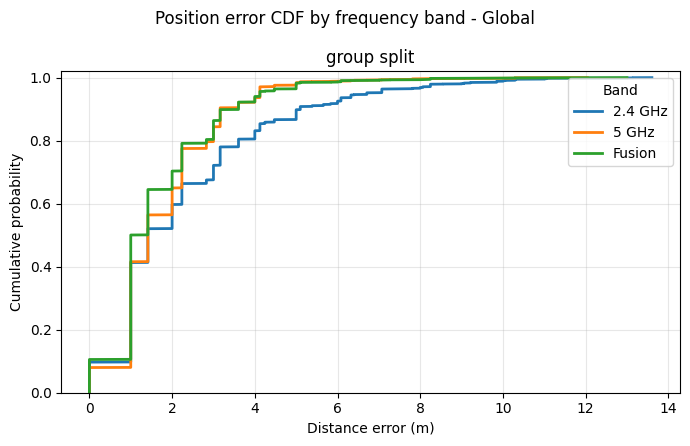

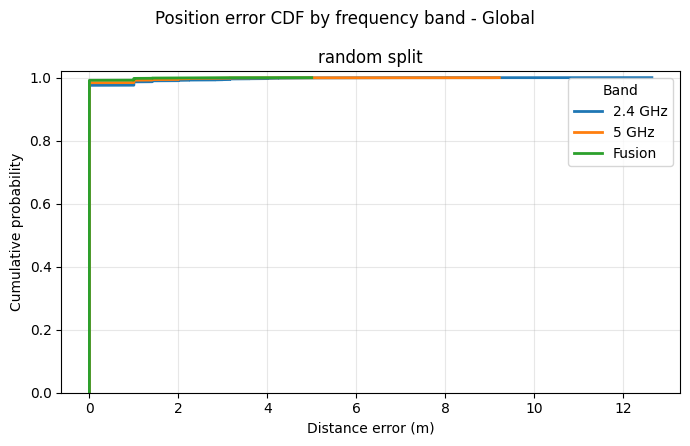

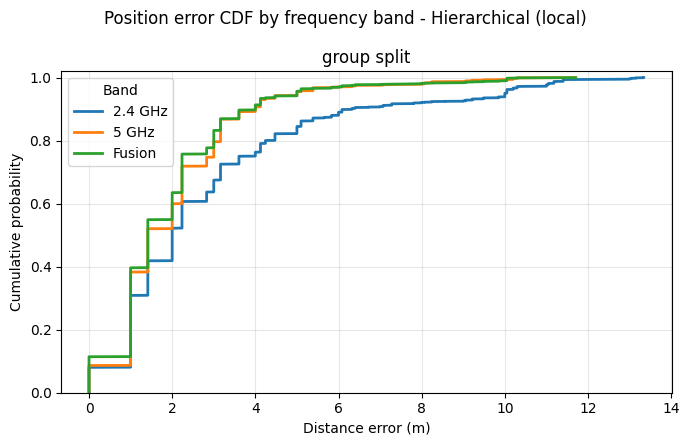

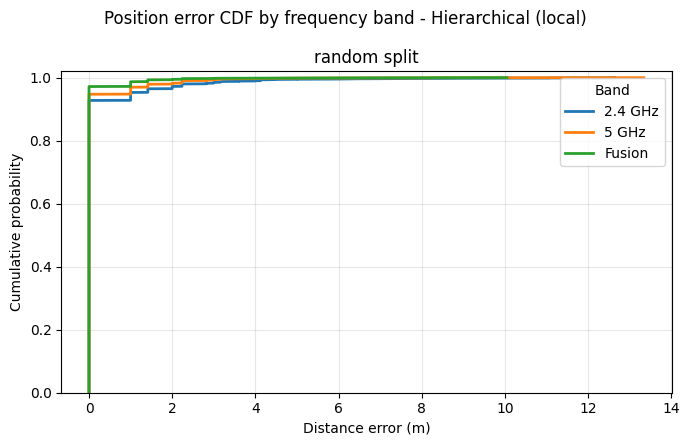

In [18]:
if SHOW_CDF_PLOTS:
    plot_band_error_cdf(global_all, model_label="Global", save_path=plots_dir)
    plot_band_error_cdf(hier_local_all, model_label="Hierarchical (local)", save_path=plots_dir)


### CDF — KNN baselines vs RF

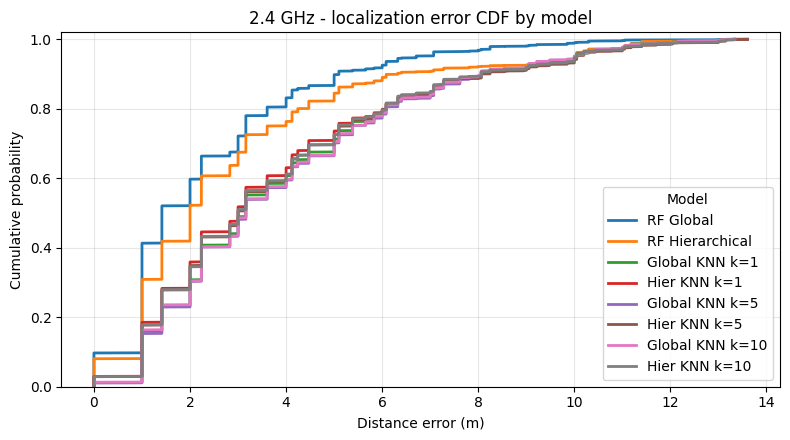

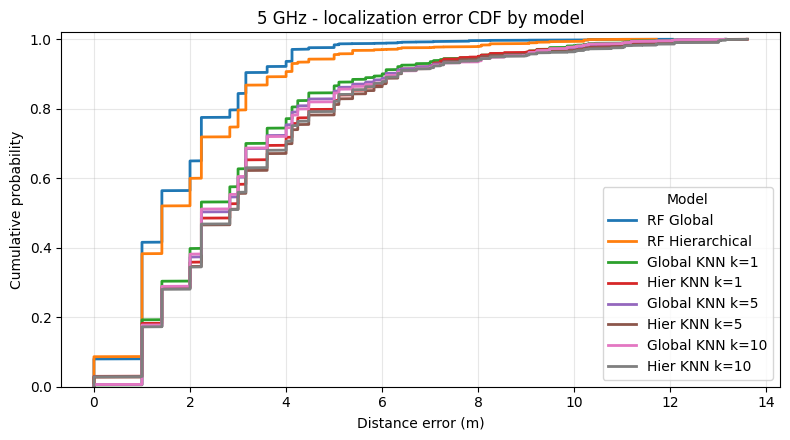

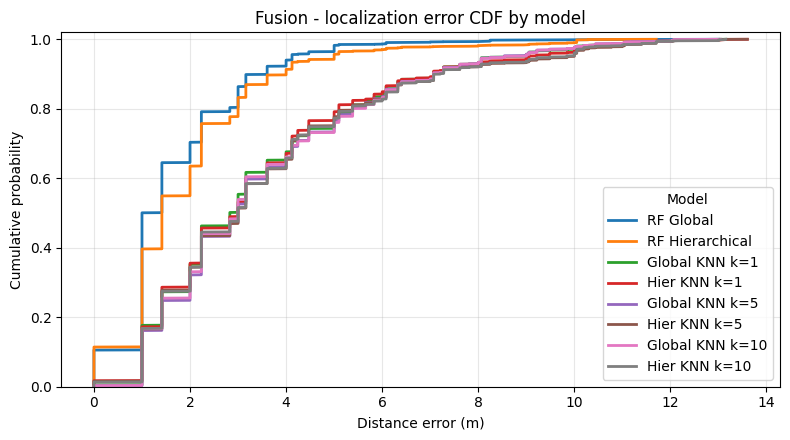

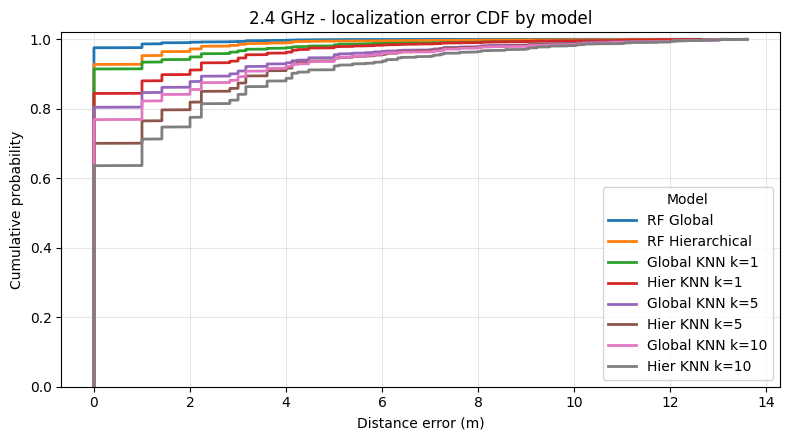

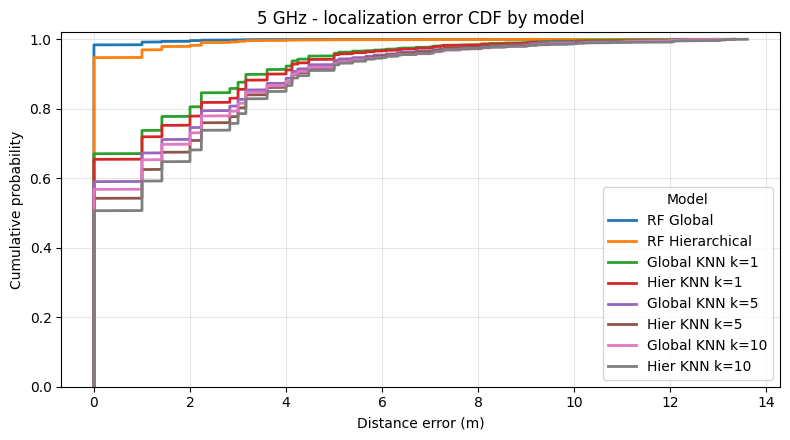

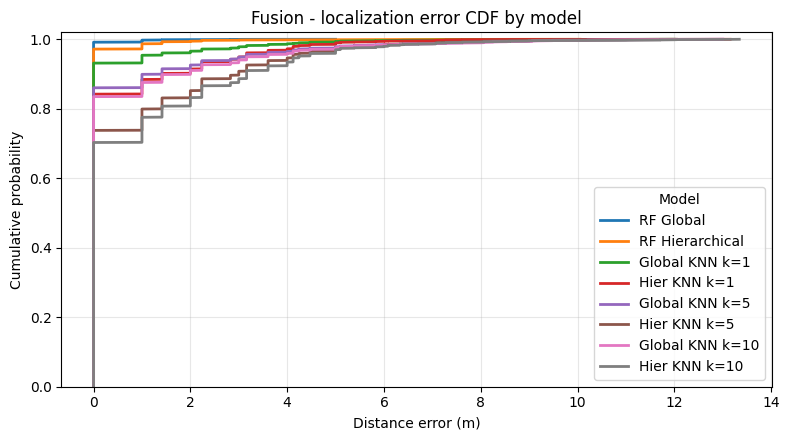

In [19]:
if SHOW_CDF_PLOTS:
    for split_mode in SPLIT_MODES:
        for band in ["2.4 GHz", "5 GHz", "Fusion"]:
            frames = []
            rf_g = global_preds_by_split.get((band, split_mode), pd.DataFrame())
            if not rf_g.empty:
                frames.append(rf_g.assign(model="RF Global", dataset=band))
            rf_h = hier_local_preds.get((band, split_mode), pd.DataFrame())
            if not rf_h.empty:
                frames.append(rf_h.assign(model="RF Hierarchical", dataset=band))
            for k in K_VALUES:
                kg = global_knn_preds_by_split.get((band, split_mode, k), pd.DataFrame())
                if not kg.empty:
                    frames.append(kg.assign(model=f"Global KNN k={k}", dataset=band))
                kh = hier_knn_preds_by_split.get((band, split_mode, k), pd.DataFrame())
                if not kh.empty:
                    frames.append(kh.assign(model=f"Hier KNN k={k}", dataset=band))
            if not frames:
                continue
            combined_preds = pd.concat(frames, ignore_index=True)
            fname = f"cdf_knn_{_slugify(band)}_{split_mode}.png"
            plot_localization_error_cdf_by_model(
                combined_preds,
                dataset=band,
                save_path=plots_dir / fname,
            )

### Box plot — distance error by frequency band

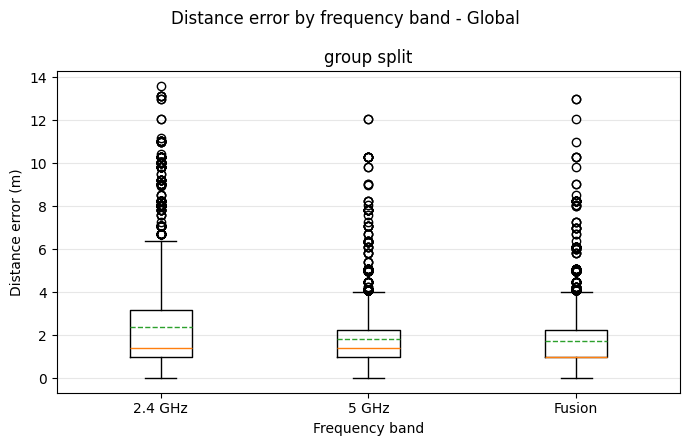

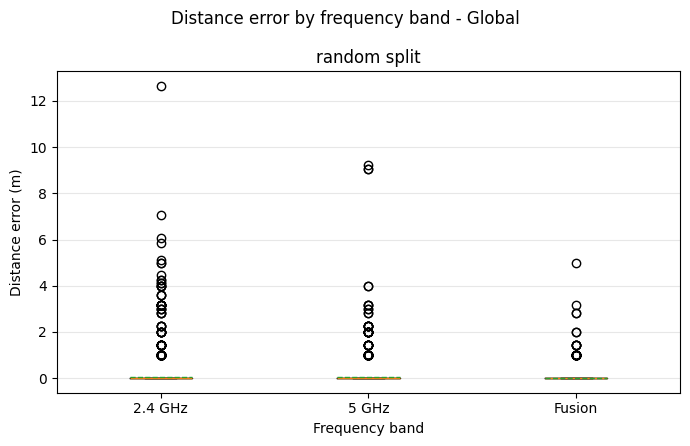

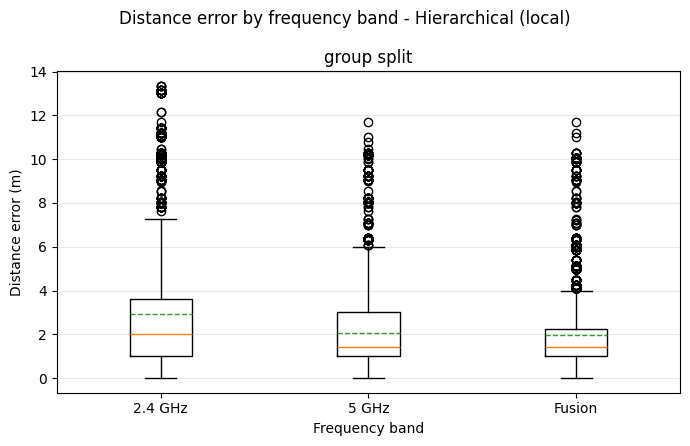

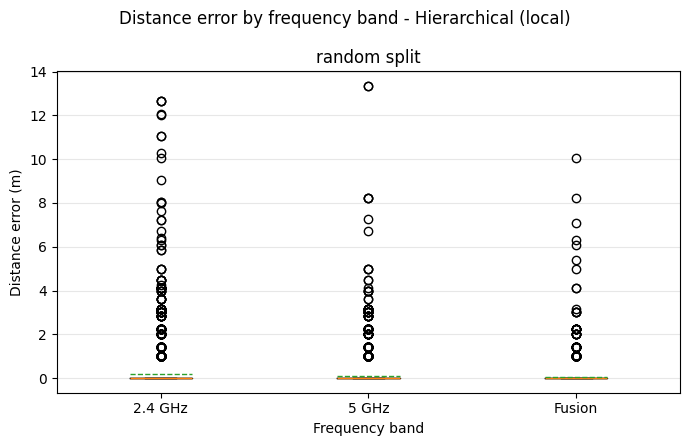

In [20]:
if SHOW_BOXPLOT:
    plot_band_error_boxplot(global_all, model_label="Global", save_path=plots_dir)
    plot_band_error_boxplot(
        hier_local_all, model_label="Hierarchical (local)", save_path=plots_dir
    )


## Floor Plan Heatmap

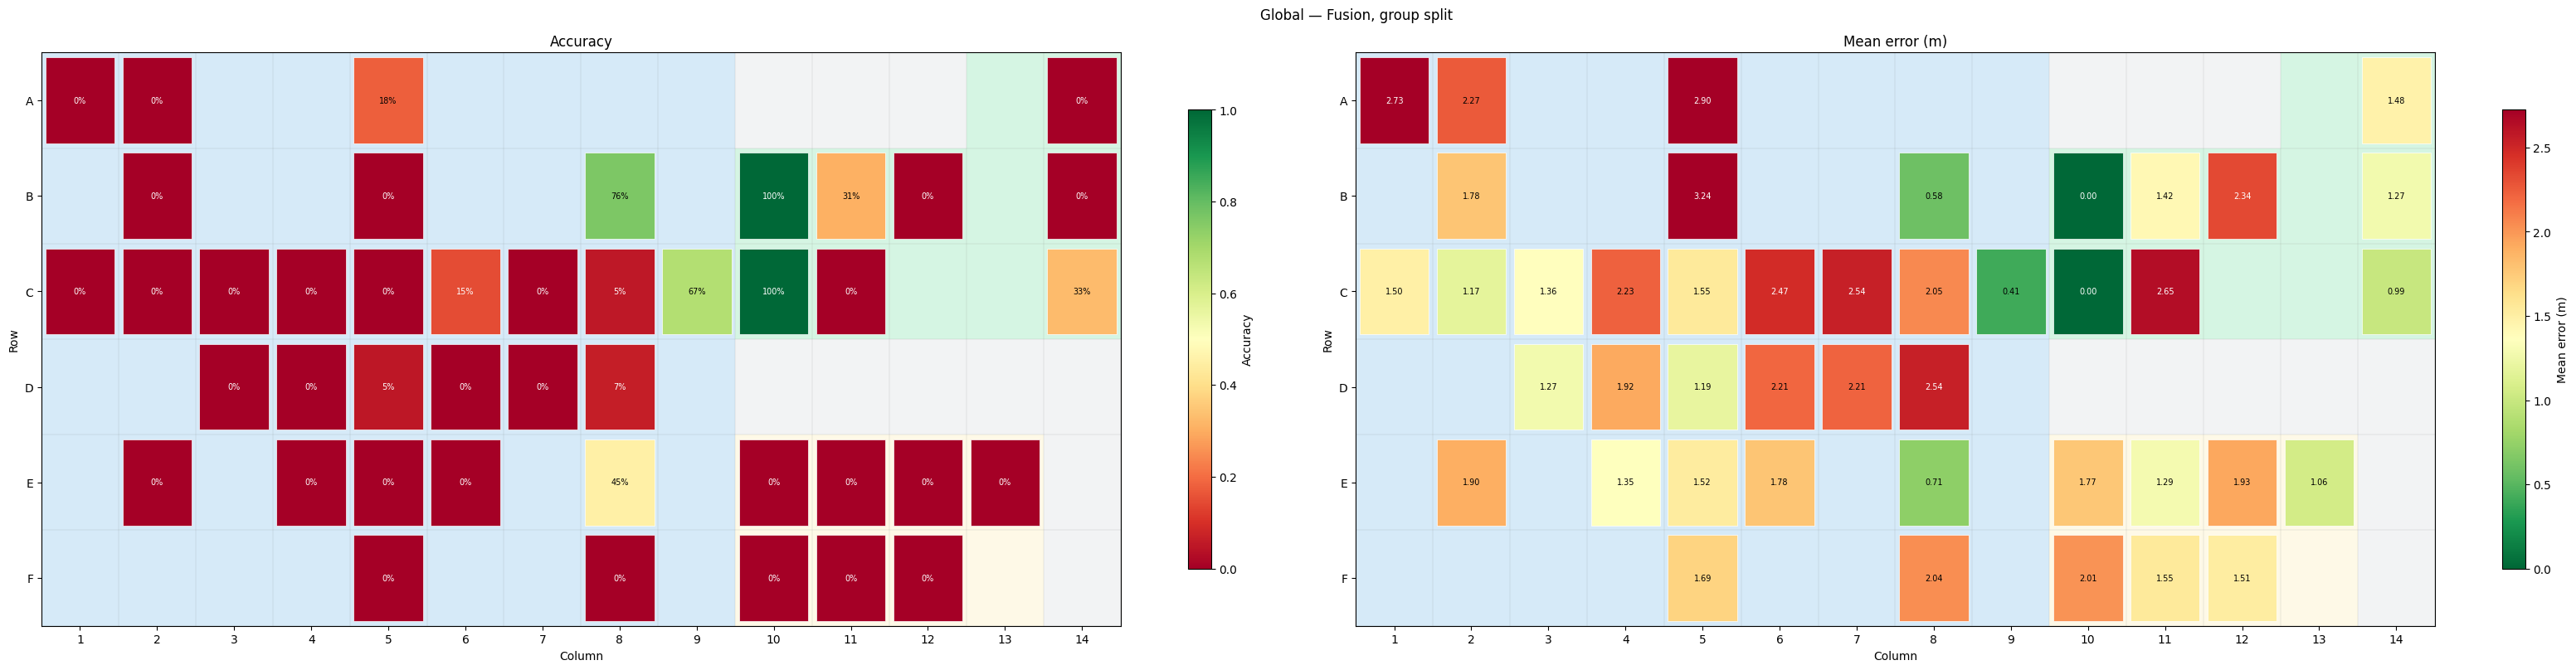

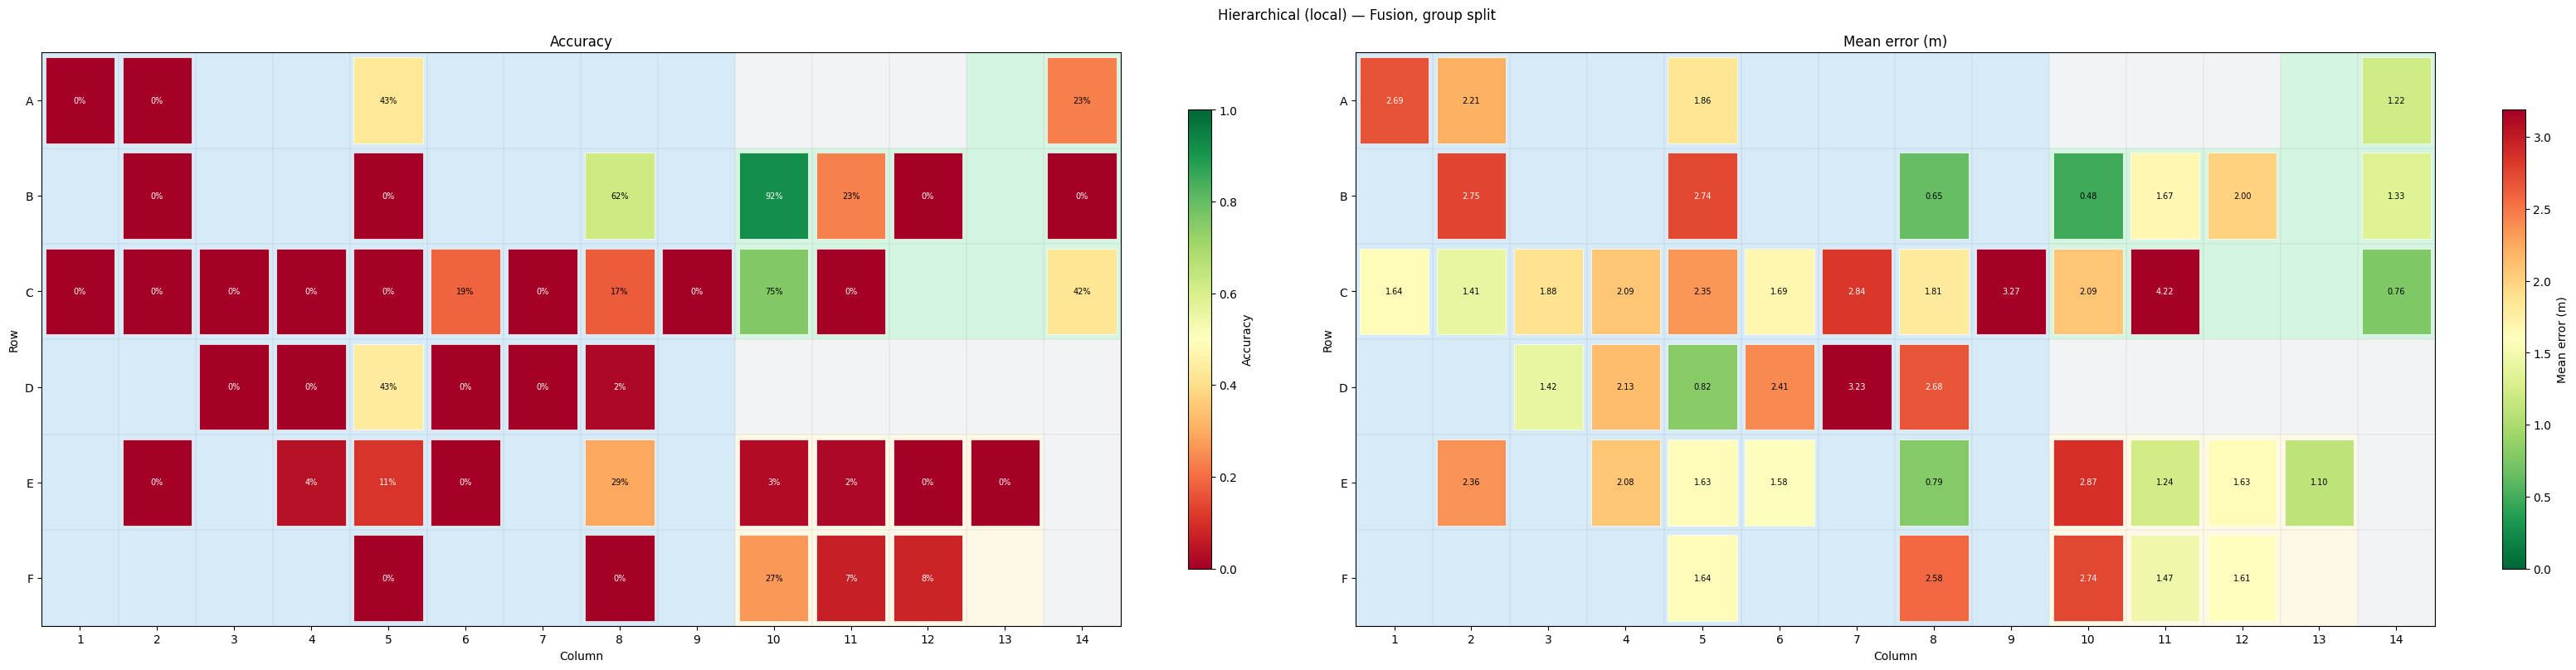

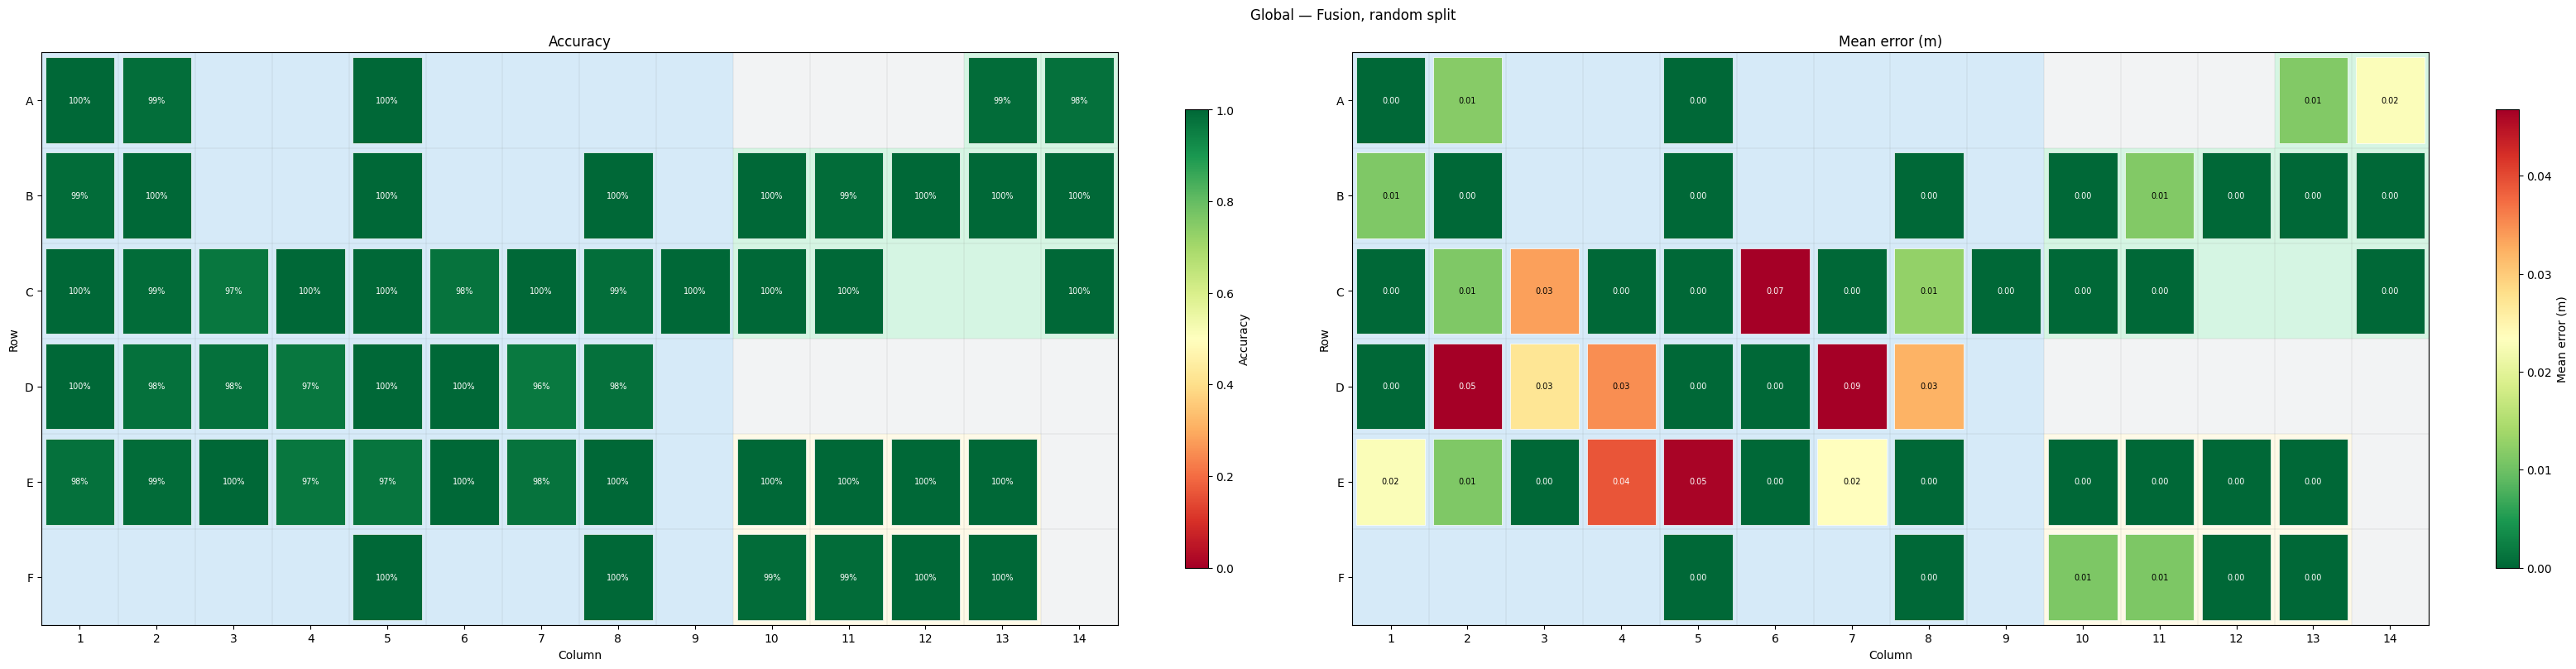

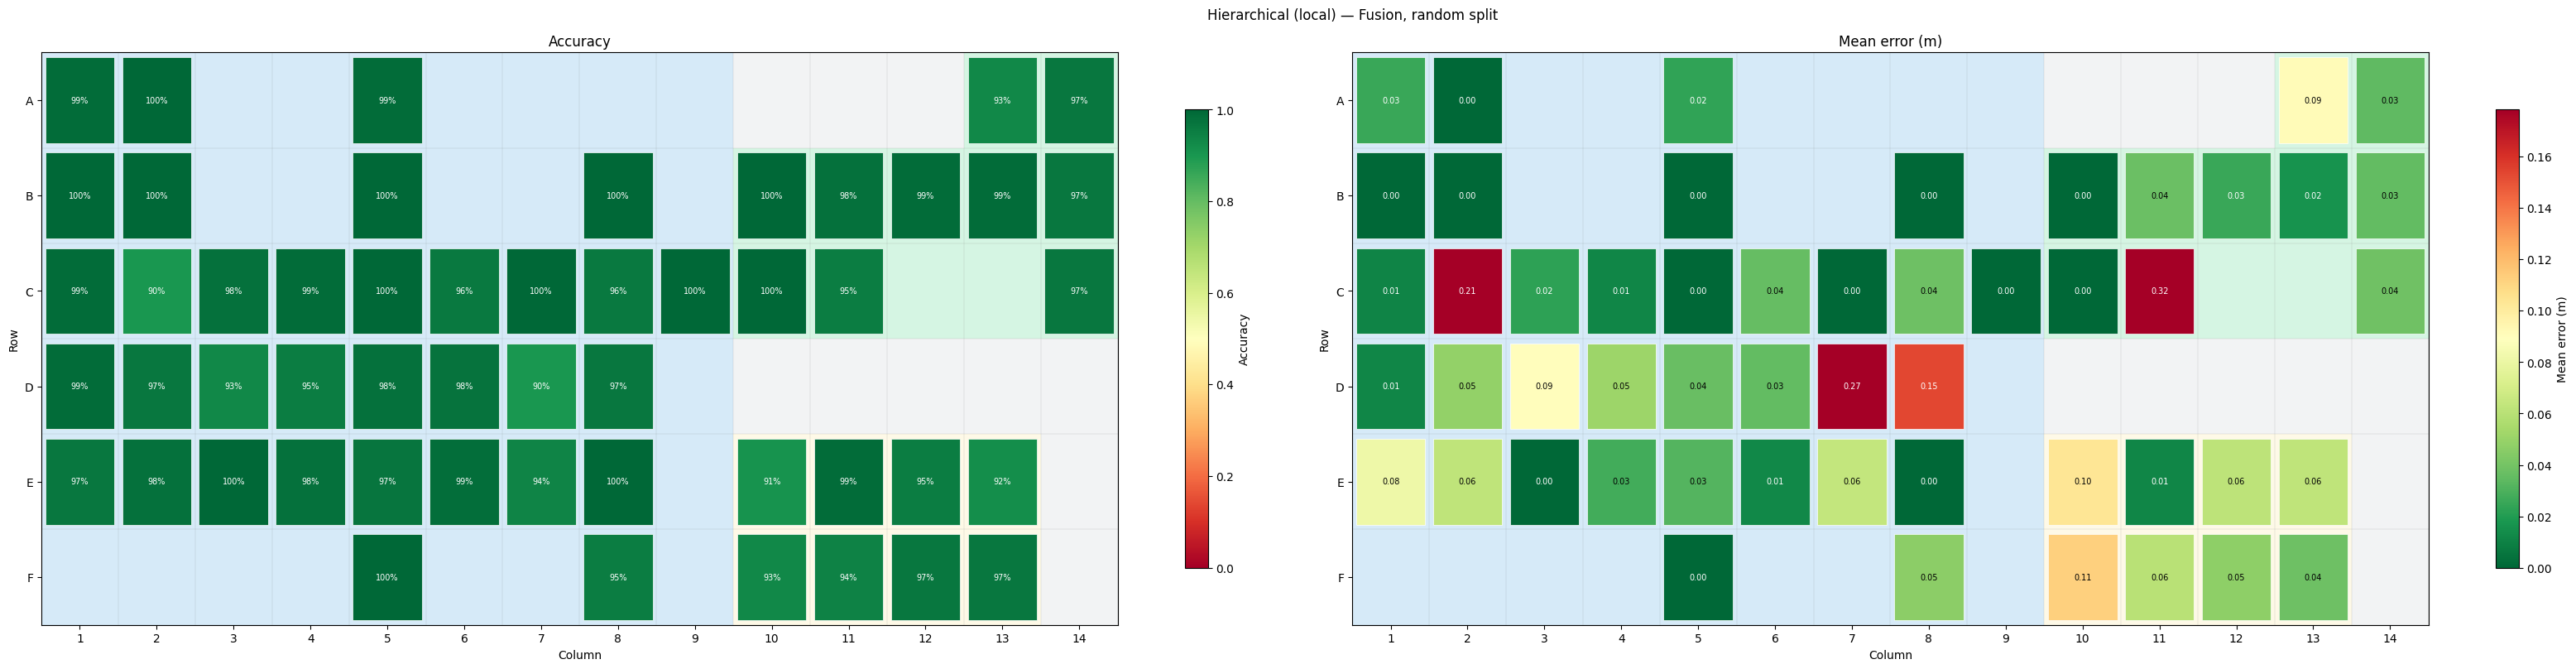

In [21]:
if SHOW_FLOOR_PLAN:
    for split_mode in SPLIT_MODES:
        for model_label, preds_dict in [
            ("Global", global_preds_by_split),
            ("Hierarchical (local)", hier_local_preds),
        ]:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                print(f"No predictions for {model_label} / {CONFUSION_DATASET} / {split_mode}")
                continue
            fname = (
                f"floorplan_{_slugify(model_label)}"
                f"_{_slugify(CONFUSION_DATASET)}_{split_mode}.png"
            )
            plot_floor_plan_heatmap(
                preds,
                title=f"{model_label} — {CONFUSION_DATASET}, {split_mode} split",
                save_path=plots_dir / fname,
            )


## Position Confusion Matrices

In [22]:
if SHOW_CONFUSION_MATRICES:
    for model_label, preds_dict in [
        ("Global", global_preds_by_split),
        ("Hierarchical (local)", hier_local_preds),
    ]:
        for split_mode in SPLIT_MODES:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                continue
            tagged = preds.assign(model=model_label)
            print(f"\n--- {model_label} / {CONFUSION_DATASET} / {split_mode} split ---")
            fname = (
                f"confusion_{_slugify(model_label)}"
                f"_{_slugify(CONFUSION_DATASET)}_{split_mode}.png"
            )
            plot_global_position_confusion_matrix(
                tagged,
                dataset=CONFUSION_DATASET,
                save_path=plots_dir / fname,
            )


## Per-Room Analysis — Hierarchical (local)

In [23]:
# Per-room accuracy and error breakdown for the local hierarchical model, both splits.
for split_mode in SPLIT_MODES:
    preds = hier_local_preds.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
    if preds.empty:
        print(f"No predictions for {CONFUSION_DATASET} / {split_mode}")
        continue
    print(f"\n=== Hierarchical (local) — {split_mode} split ===")
    display(per_room_hierarchical_summary(preds))

    if SHOW_PER_ROOM_PLOTS:
        tagged = preds.assign(model="Hierarchical (local)")
        plot_position_confusion_by_true_room(tagged, dataset=CONFUSION_DATASET)
        plot_position_confusion_when_room_correct(tagged, dataset=CONFUSION_DATASET)


=== Hierarchical (local) — group split ===


,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,Fusion,2,795,0.903145,0.240252,1.954086,1.000000,3.156106
1,Fusion,1,2815,0.999290,0.093783,2.018255,2.000000,2.407286
2,Fusion,3,882,0.890023,0.065760,1.820468,1.414214,2.585061
3,Fusion,0,121,0.000000,0.000000,NaN,NaN,NaN



=== Hierarchical (local) — random split ===


,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,Fusion,1,2949,1.000000,0.976263,0.041064,0.0,0.330438
1,Fusion,3,715,0.997203,0.948252,0.062073,0.0,0.294884
2,Fusion,2,869,0.996548,0.973533,0.059830,0.0,0.538506
3,Fusion,0,90,0.988889,0.988889,NaN,NaN,NaN


In [24]:
write_manifest(
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    classifier_params={
        "n_estimators": 300,
        "max_features": "sqrt",
        "random_state": RANDOM_STATE,
        "class_weight": "balanced",
    },
    splits=list(SPLIT_MODES),
    test_size=TEST_SIZE,
    feature_dataframes=feature_dataframes,
)


[results] Manifest written to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\manifest.json


## Window-size sensitivity analysis

This section sweeps the packet-window configuration while keeping the paper preprocessing settings fixed. It evaluates the same dataset, split, classifier, and architecture matrix for each window configuration, then writes the consolidated sensitivity tables and comparison plot used in the paper.

In [25]:
import gc

import matplotlib.pyplot as plt
import numpy as np

from utils.cache import RESULTS_ROOT, get_dataframe, make_feat_key, make_preproc_key
from utils.feature_pipeline import build_frequency_feature_dataframe
from utils.window_configs import WINDOW_CONFIGS

SENSITIVITY_FEATURE_BASE_OPTIONS = {
    "calibrate": FEATURE_EXTRACTION_OPTIONS["calibrate"],
    "require_all_esps": FEATURE_EXTRACTION_OPTIONS["require_all_esps"],
}
SENSITIVITY_BANDS = (
    ("2.4 GHz", "2.4ghz"),
    ("5 GHz", "5ghz"),
    ("Fusion", "fusion"),
)
SENSITIVITY_K_VALUES = (1,)
SENSITIVITY_ROWS_PER_WINDOW = 24
SENSITIVITY_BASELINE_WINDOW_SIZE = 60
SENSITIVITY_BASELINE_STEP = 30
SENSITIVITY_COLUMNS = [
    "window_label",
    "window_size",
    "step",
    "dataset",
    "classifier",
    "architecture",
    "split",
    "k",
    "position_accuracy",
    "room_accuracy",
    "mean_distance_error",
    "median_distance_error",
    "rmse_distance_error",
    "samples",
]
SENSITIVITY_MODEL_MAP = {
    "global_position_rf": ("RF", "Global"),
    "hierarchical_rf": ("RF", "Hierarchical"),
    "global_position_knn": ("KNN", "Global"),
    "hierarchical_knn": ("KNN", "Hierarchical"),
}

SENSITIVITY_BASELINE_OBJECTS_TO_RELEASE = [
    "feature_dataframes",
    "df_24ghz",
    "df_5ghz",
    "df_fusion",
    "global_preds_by_split",
    "global_models_by_split",
    "hier_local_preds",
    "hier_local_models",
    "global_knn_preds_by_split",
    "global_knn_models",
    "hier_knn_preds_by_split",
    "hier_knn_models",
    "global_all",
    "hier_local_all",
    "all_preds",
    "combined_preds",
    "preds",
    "tagged",
]
for _name in SENSITIVITY_BASELINE_OBJECTS_TO_RELEASE:
    if _name in globals():
        del globals()[_name]
gc.collect()


def _sensitivity_preprocessing_is_noop() -> bool:
    return (
        not bool(preproc_opts.get("apply_agc_compensation", False))
        and str(preproc_opts.get("filter_method", "none")).lower() in {"none", ""}
        and str(preproc_opts.get("normalization", "none")).lower() in {"none", ""}
    )


_sensitivity_processed_magnitude_data = None


def _sensitivity_feat_opts(window_size: int, step: int) -> dict:
    return {
        "window_size": window_size,
        "step": step,
        **SENSITIVITY_FEATURE_BASE_OPTIONS,
    }


def _sensitivity_build_opts(feat_opts: dict) -> dict:
    window_size = int(feat_opts["window_size"])
    step = int(feat_opts["step"])
    if step <= 0 or step > window_size:
        msg = f"Invalid step={step} for window_size={window_size}"
        raise ValueError(msg)
    return {
        "window_size": window_size,
        "overlap_size": window_size - step,
        "calibrate": bool(feat_opts.get("calibrate", False)),
        "require_all_esps": bool(feat_opts.get("require_all_esps", False)),
    }


def _sensitivity_processed_magnitudes() -> object:
    global _sensitivity_processed_magnitude_data
    if _sensitivity_preprocessing_is_noop():
        return magnitude_data
    if _sensitivity_processed_magnitude_data is None:
        processed, _ = process_magnitude_data(magnitude_data, agc_gain_data, **preproc_opts)
        _sensitivity_processed_magnitude_data = processed
    return _sensitivity_processed_magnitude_data


def _build_sensitivity_band_dataframe(
    feat_key: str,
    feat_opts: dict,
    scenario: str,
) -> pd.DataFrame:
    processed = _sensitivity_processed_magnitudes()
    return build_frequency_feature_dataframe(
        processed,
        scenario,
        **_sensitivity_build_opts(feat_opts),
    )


def _load_sensitivity_dataframes(feat_key: str, feat_opts: dict) -> dict[str, pd.DataFrame]:
    feature_dataframes = {}
    for dataset_name, scenario in SENSITIVITY_BANDS:
        feature_dataframes[dataset_name] = get_dataframe(
            dataset_name,
            preproc_opts,
            feat_opts,
            lambda scenario=scenario: _build_sensitivity_band_dataframe(
                feat_key,
                feat_opts,
                scenario,
            ),
        )
    return feature_dataframes


def _summary_to_sensitivity_rows(
    summary: pd.DataFrame,
    *,
    window_label: str,
    window_size: int,
    step: int,
) -> pd.DataFrame:
    rows = []
    for _, row in summary.iterrows():
        model_name = str(row.get("model", ""))
        if model_name not in SENSITIVITY_MODEL_MAP:
            continue

        classifier, architecture = SENSITIVITY_MODEL_MAP[model_name]
        if architecture == "Hierarchical" and str(row.get("esp_mode", "")) != "local":
            continue

        k_value = row.get("k", np.nan)
        if classifier == "KNN":
            if pd.isna(k_value) or int(float(k_value)) != 1:
                continue
            k_out = 1
        else:
            k_out = np.nan

        rows.append(
            {
                "window_label": window_label,
                "window_size": window_size,
                "step": step,
                "dataset": row.get("dataset"),
                "classifier": classifier,
                "architecture": architecture,
                "split": row.get("split"),
                "k": k_out,
                "position_accuracy": row.get("position_accuracy"),
                "room_accuracy": row.get("room_accuracy"),
                "mean_distance_error": row.get("mean_distance_error"),
                "median_distance_error": row.get("median_distance_error"),
                "rmse_distance_error": row.get("rmse_distance_error"),
                "samples": row.get("samples"),
            },
        )

    result = pd.DataFrame(rows, columns=SENSITIVITY_COLUMNS)
    if result.empty:
        return result
    return result.sort_values(
        ["window_size", "step", "dataset", "split", "classifier", "architecture"],
    ).reset_index(drop=True)


def _has_complete_sensitivity_rows(rows: pd.DataFrame) -> bool:
    if len(rows) != SENSITIVITY_ROWS_PER_WINDOW:
        return False
    key_cols = ["dataset", "split", "classifier", "architecture"]
    if rows.duplicated(key_cols).any():
        return False
    expected = {
        (dataset, split, classifier, architecture)
        for dataset, _ in SENSITIVITY_BANDS
        for split in SPLIT_MODES
        for classifier, architecture in (
            ("RF", "Global"),
            ("RF", "Hierarchical"),
            ("KNN", "Global"),
            ("KNN", "Hierarchical"),
        )
    }
    observed = set(rows[key_cols].itertuples(index=False, name=None))
    return observed == expected


def _run_sensitivity_window(window_label: str, window_size: int, step: int) -> pd.DataFrame:
    feat_opts_for_window = _sensitivity_feat_opts(window_size, step)
    feat_key = make_feat_key(feat_opts_for_window)
    if feat_key != window_label:
        msg = f"Cache key mismatch: {feat_key!r} != {window_label!r}"
        raise ValueError(msg)

    sensitivity_results_dir = get_results_path(preproc_opts, feat_opts_for_window)
    (sensitivity_results_dir / "plots").mkdir(parents=True, exist_ok=True)

    print(f"\n=== {window_label}: window_size={window_size}, step={step} ===")
    sensitivity_feature_dataframes = _load_sensitivity_dataframes(feat_key, feat_opts_for_window)
    for dataset_name, dataframe in sensitivity_feature_dataframes.items():
        print(f"{dataset_name}: {dataframe.shape[0]} windows, {dataframe.shape[1]} columns")

    summary_path = sensitivity_results_dir / "summary.csv"
    sensitivity_summary_for_window = pd.DataFrame()
    if summary_path.exists():
        candidate_summary = pd.read_csv(summary_path, index_col=0)
        candidate_rows = _summary_to_sensitivity_rows(
            candidate_summary,
            window_label=window_label,
            window_size=window_size,
            step=step,
        )
        if _has_complete_sensitivity_rows(candidate_rows):
            print(f"[results hit] {summary_path}")
            sensitivity_summary_for_window = candidate_summary

    if sensitivity_summary_for_window.empty:
        global_sensitivity_summary, _, _ = run_global_position_experiments_by_split(
            sensitivity_feature_dataframes,
            split_modes=SPLIT_MODES,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
        )
        hier_sensitivity_summary, _, _ = run_hierarchical_position_experiments_by_split(
            sensitivity_feature_dataframes,
            split_modes=SPLIT_MODES,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
            esp_mode="local",
            room_local_esps=ROOM_LOCAL_ESPS,
        )
        global_knn_sensitivity_summary, _, _ = run_global_position_experiments_by_split_knn(
            sensitivity_feature_dataframes,
            k_values=SENSITIVITY_K_VALUES,
            split_modes=SPLIT_MODES,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
        )
        hier_knn_sensitivity_summary, _, _ = run_hierarchical_position_experiments_by_split_knn(
            sensitivity_feature_dataframes,
            k_values=SENSITIVITY_K_VALUES,
            split_modes=SPLIT_MODES,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
            esp_mode="local",
            room_local_esps=ROOM_LOCAL_ESPS,
        )
        sensitivity_summary_for_window = combine_position_experiment_summaries(
            global_sensitivity_summary,
            hier_sensitivity_summary,
            pd.DataFrame(),
            global_knn_summary=global_knn_sensitivity_summary,
            hierarchical_knn_summary=hier_knn_sensitivity_summary,
        )
        save_summary(sensitivity_summary_for_window, sensitivity_results_dir)

    manifest_path = sensitivity_results_dir / "manifest.json"
    if not manifest_path.exists():
        write_manifest(
            results_dir=sensitivity_results_dir,
            preproc_opts=preproc_opts,
            feat_opts=feat_opts_for_window,
            classifier_params={
                "rf": {
                    "n_estimators": 300,
                    "max_features": "sqrt",
                    "random_state": RANDOM_STATE,
                    "class_weight": "balanced",
                },
                "knn": {"k_values": list(SENSITIVITY_K_VALUES)},
                "hierarchical": {"esp_mode": "local", "room_local_esps": ROOM_LOCAL_ESPS},
            },
            splits=list(SPLIT_MODES),
            test_size=TEST_SIZE,
            feature_dataframes=sensitivity_feature_dataframes,
        )

    sensitivity_rows_for_window = _summary_to_sensitivity_rows(
        sensitivity_summary_for_window,
        window_label=window_label,
        window_size=window_size,
        step=step,
    )
    if not _has_complete_sensitivity_rows(sensitivity_rows_for_window):
        msg = (
            f"{window_label} produced {len(sensitivity_rows_for_window)} sensitivity rows; "
            f"expected {SENSITIVITY_ROWS_PER_WINDOW}."
        )
        raise ValueError(msg)
    return sensitivity_rows_for_window


sensitivity_rows_by_window = []
for window_label, window_size, step in WINDOW_CONFIGS:
    sensitivity_rows_by_window.append(_run_sensitivity_window(window_label, window_size, step))



=== win30-step30: window_size=30, step=30 ===
[cache miss] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win30-step30\2_4ghz.parquet, computing...
[cache miss] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win30-step30\5ghz.parquet, computing...
[cache miss] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win30-step30\fusion.parquet, computing...
2.4 GHz: 15717 windows, 2708 columns
5 GHz: 16692 windows, 3368 columns
Fusion: 15675 windows, 6068 columns
[results] Summary saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win30-step30/
[results] Manifest written to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\pr

In [26]:
def _save_sensitivity_table(dataframe: pd.DataFrame, stem: Path) -> None:
    stem.parent.mkdir(parents=True, exist_ok=True)
    dataframe.to_csv(stem.with_suffix(".csv"), index=False)
    stem.with_suffix(".md").write_text(dataframe.to_markdown(index=False), encoding="utf-8")
    tex = dataframe.to_latex(index=False, escape=False, float_format="%.4f")
    stem.with_suffix(".tex").write_text(tex, encoding="utf-8")


sensitivity_dir = RESULTS_ROOT / f"preproc={make_preproc_key(preproc_opts)}" / "sensitivity"
sensitivity_summary = pd.concat(sensitivity_rows_by_window, ignore_index=True)
expected_sensitivity_rows = len(WINDOW_CONFIGS) * SENSITIVITY_ROWS_PER_WINDOW
if len(sensitivity_summary) != expected_sensitivity_rows:
    msg = f"Expected {expected_sensitivity_rows} sensitivity rows, got {len(sensitivity_summary)}"
    raise ValueError(msg)

_save_sensitivity_table(sensitivity_summary, sensitivity_dir / "sensitivity_summary")
print(f"[results] Sensitivity summary saved to {sensitivity_dir}")
display(sensitivity_summary)


[results] Sensitivity summary saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\sensitivity


,window_label,window_size,step,dataset,classifier,architecture,split,k,position_accuracy,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,win30-step30,30,30,2.4 GHz,KNN,Global,group,1.0,0.009131,NaN,4.032990,3.162278,4.937561,4709.0
1,win30-step30,30,30,2.4 GHz,KNN,Hierarchical,group,1.0,0.029730,0.644935,3.898067,3.000000,4.898842,4709.0
2,win30-step30,30,30,2.4 GHz,RF,Global,group,NaN,0.085793,NaN,2.444587,2.000000,3.270840,4709.0
3,win30-step30,30,30,2.4 GHz,RF,Hierarchical,group,NaN,0.075812,0.846252,2.969190,2.000000,4.069879,4709.0
4,win30-step30,30,30,2.4 GHz,KNN,Global,random,1.0,0.625106,NaN,1.384772,0.000000,2.864321,4716.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,win120-step120,120,120,Fusion,RF,Hierarchical,group,NaN,0.111111,0.932633,1.922870,1.414214,2.542540,1143.0
116,win120-step120,120,120,Fusion,KNN,Global,random,1.0,0.692845,NaN,0.813887,0.000000,1.886512,1146.0
117,win120-step120,120,120,Fusion,KNN,Hierarchical,random,1.0,0.577661,0.954625,1.144548,0.000000,2.179040,1146.0
118,win120-step120,120,120,Fusion,RF,Global,random,NaN,0.929319,NaN,0.134775,0.000000,0.737341,1146.0


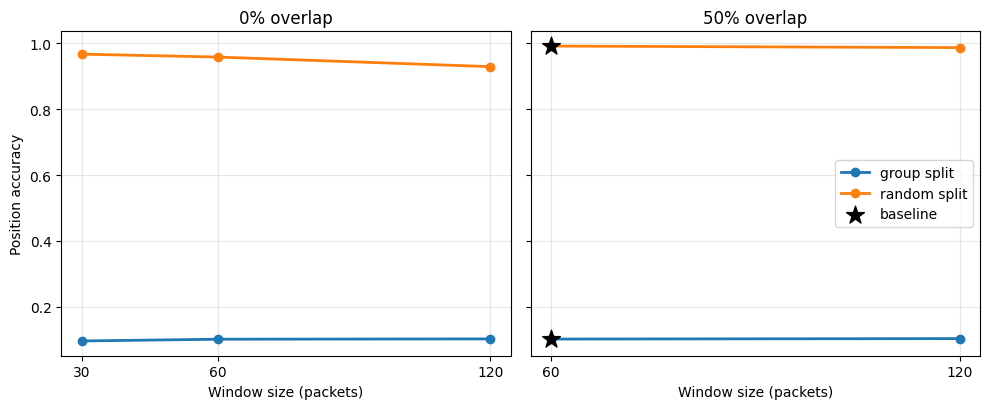

[results] Sensitivity paper table saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\sensitivity
[results] Sensitivity plot saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\sensitivity\plots\sensitivity_position_accuracy.png


,window_size,step,split,position_accuracy,mean_distance_error,rmse_distance_error
0,30,30,group,0.096101,1.843939,2.371988
1,30,30,random,0.967255,0.056694,0.367575
2,60,30,group,0.101886,1.714773,2.190890
3,60,30,random,0.991780,0.011447,0.145527
4,60,60,group,0.101505,1.768183,2.269376
5,60,60,random,0.958458,0.074158,0.490076
6,120,60,group,0.103341,1.672261,2.125185
7,120,60,random,0.987140,0.023371,0.230037
8,120,120,group,0.102362,1.689160,2.137331
9,120,120,random,0.929319,0.134775,0.737341


In [27]:
sensitivity_paper_table = (
    sensitivity_summary.loc[
        (sensitivity_summary["dataset"] == "Fusion")
        & (sensitivity_summary["classifier"] == "RF")
        & (sensitivity_summary["architecture"] == "Global"),
        [
            "window_size",
            "step",
            "split",
            "position_accuracy",
            "mean_distance_error",
            "rmse_distance_error",
        ],
    ]
    .sort_values(["window_size", "step", "split"])
    .reset_index(drop=True)
)
expected_paper_rows = len(WINDOW_CONFIGS) * len(SPLIT_MODES)
if len(sensitivity_paper_table) != expected_paper_rows:
    msg = f"Expected {expected_paper_rows} paper-table rows, got {len(sensitivity_paper_table)}"
    raise ValueError(msg)

_save_sensitivity_table(sensitivity_paper_table, sensitivity_dir / "sensitivity_paper_table")

sensitivity_plot_dir = sensitivity_dir / "plots"
sensitivity_plot_dir.mkdir(parents=True, exist_ok=True)
sensitivity_plot_path = sensitivity_plot_dir / "sensitivity_position_accuracy.png"

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
panel_specs = [
    ("0% overlap", lambda table: table["step"] == table["window_size"]),
    ("50% overlap", lambda table: table["step"] * 2 == table["window_size"]),
]
for ax, (title, selector) in zip(axes, panel_specs):
    panel = sensitivity_paper_table.loc[selector(sensitivity_paper_table)].copy()
    for split_mode in SPLIT_MODES:
        split_table = panel.loc[panel["split"] == split_mode].sort_values("window_size")
        if split_table.empty:
            continue
        ax.plot(
            split_table["window_size"],
            split_table["position_accuracy"],
            marker="o",
            linewidth=2,
            label=f"{split_mode} split",
        )

    baseline = panel.loc[
        (panel["window_size"] == SENSITIVITY_BASELINE_WINDOW_SIZE)
        & (panel["step"] == SENSITIVITY_BASELINE_STEP)
    ]
    if not baseline.empty:
        ax.scatter(
            baseline["window_size"],
            baseline["position_accuracy"],
            marker="*",
            s=180,
            color="black",
            label="baseline" if title == "50% overlap" else None,
            zorder=5,
        )

    ax.set_title(title)
    ax.set_xlabel("Window size (packets)")
    ax.set_xticks(sorted(panel["window_size"].unique()))
    ax.grid(visible=True, alpha=0.3)

axes[0].set_ylabel("Position accuracy")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="best")
fig.tight_layout()
fig.savefig(sensitivity_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[results] Sensitivity paper table saved to {sensitivity_dir}")
print(f"[results] Sensitivity plot saved to {sensitivity_plot_path}")
display(sensitivity_paper_table)
